# Prepare the dataset with the full set of features to use in Feature Selection process.

We need to:
1. Merge metadata with point-value metrics
2. Merge metadata with time-series features
3. Remove outliers and missing data

Save the resulting dataset for Feature Selection process: RICKD_FEATURE_SELECTION_DATA_FILE

In [1]:
import core.constants as c

from core.matlab_data_loader import MatlabDataLoader
from core.markers import visualize_marker_trajectories
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
loader = MatlabDataLoader()

full_data = loader.get_discrete_with_metadata()
display(full_data.head())

,ID,Speed_Output,Label,Hz,Step_Width_Left,Step_Width_Right,Stride_Rate_Left,Stride_Rate_Right,Stride_Length_Left,Stride_Length_Right,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
0,100001_20110531T161051,2.489233,run,200,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,left,right,False,True
1,100002_20110601T140505,2.722687,run,200,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,...,Painful friction of iliotibial band rubbing ov...,No injury has been diagnosed.,itb syndrome,no injury,thigh,no_injury,right,right,False,True
2,100003_20110601T095930,2.949904,run,200,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,...,Pain around kneecap caused by poor tracking an...,General sensation of discomfort without speci...,patellofemoral pain syndrome,pain,knee,foot,left,left,False,True
3,100004_20110203T120721,2.688014,run,200,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,right,False,True
4,100004_20140929T102035,2.928598,run,200,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


## Columns Selection

NOTES:
- We have removed columns that are not useful for our analysis, like the years running, file path, activities, ...
- We have also removed duplicate values like speed_r.
- When information is present in both discrete variables file and metadata file, we have taken the discrete variables file as we have been the ones that have computed the values.
- We have removed columns that have been merged into is_injured (injury_code, injury_severity, injured_side, etc..).

### Columns to Keep:

| #   | Column                          | Dtype    |
|-----|---------------------------------|----------|
| 0   | ID                              | object   |
| 1   | Speed_Output                    | float64  |
| 3   | Hz                              | int64    |
| 4   | Step_Width_Left                 | float64  |
| 5   | Step_Width_Right                | float64  |
| 6   | Stride_Rate_Left                | float64  |
| 7   | Stride_Rate_Right               | float64  |
| 8   | Stride_Length_Left              | float64  |
| 9   | Stride_Length_Right             | float64  |
| 10  | Swing_Time_Left                 | float64  |
| 11  | Swing_Time_Right                | float64  |
| 12  | Stance_Time_Left                | float64  |
| 13  | Stance_Time_Right               | float64  |
| 14  | Pelvis_Peak_Drop_Angle_Left     | float64  |
| 15  | Pelvis_Peak_Drop_Angle_Right    | float64  |
| 16  | Pelvis_Drop_Excursion_Left      | float64  |
| 17  | Pelvis_Drop_Excursion_Right     | float64  |
| 18  | Ankle_DF_Peak_Angle_Left        | float64  |
| 19  | Ankle_DF_Peak_Angle_Right       | float64  |
| 20  | Ankle_Eve_Peak_Angle_Left       | float64  |
| 21  | Ankle_Eve_Peak_Angle_Right      | float64  |
| 22  | Ankle_Eve_Percent_Stance_Left   | float64  |
| 23  | Ankle_Eve_Percent_Stance_Right  | float64  |
| 24  | Ankle_Eve_Excursion_Left        | float64  |
| 25  | Ankle_Eve_Excursion_Right       | float64  |
| 26  | Ankle_Rot_Peak_Angle_Left       | float64  |
| 27  | Ankle_Rot_Peak_Angle_Right      | float64  |
| 28  | Ankle_Rot_Excursion_Left        | float64  |
| 29  | Ankle_Rot_Excursion_Right       | float64  |
| 30  | Knee_Flex_Peak_Angle_Left       | float64  |
| 31  | Knee_Flex_Peak_Angle_Right      | float64  |
| 32  | Knee_Add_Peak_Angle_Left        | float64  |
| 33  | Knee_Add_Peak_Angle_Right       | float64  |
| 34  | Knee_Add_Excursion_Left         | float64  |
| 35  | Knee_Add_Excursion_Right        | float64  |
| 36  | Knee_Abd_Peak_Angle_Left        | float64  |
| 37  | Knee_Abd_Peak_Angle_Right       | float64  |
| 38  | Knee_Abd_Excursion_Left         | float64  |
| 39  | Knee_Abd_Excursion_Right        | float64  |
| 40  | Knee_Rot_Peak_Angle_Left        | float64  |
| 41  | Knee_Rot_Peak_Angle_Right       | float64  |
| 42  | Knee_Rot_Excursion_Left         | float64  |
| 43  | Knee_Rot_Excursion_Right        | float64  |
| 44  | Hip_Ext_Peak_Angle_Left         | float64  |
| 45  | Hip_Ext_Peak_Angle_Right        | float64  |
| 46  | Hip_Add_Peak_Angle_Left         | float64  |
| 47  | Hip_Add_Peak_Angle_Right        | float64  |
| 48  | Hip_Add_Excursion_Left          | float64  |
| 49  | Hip_Add_Excursion_Right         | float64  |
| 50  | Hip_Rot_Peak_Angle_Left         | float64  |
| 51  | Hip_Rot_Peak_Angle_Right        | float64  |
| 52  | Hip_Rot_Excursion_Left          | float64  |
| 53  | Hip_Rot_Excursion_Right         | float64  |
| 54  | Foot_Prog_Angle_Left            | float64  |
| 55  | Foot_Prog_Angle_Right           | float64  |
| 56  | Foot_Ang_At_HS_Left             | float64  |
| 57  | Foot_Ang_At_HS_Right            | float64  |
| 58  | MHW_Exc_From_TO_Left            | float64  |
| 59  | MHW_Exc_From_TO_Right           | float64  |
| 60  | Ankle_Eve_Peak_Vel_Left         | float64  |
| 61  | Ankle_Eve_Peak_Vel_Right        | float64  |
| 62  | Ankle_Rot_Peak_Vel_Left         | float64  |
| 63  | Ankle_Rot_Peak_Vel_Right        | float64  |
| 64  | Knee_Abd_Peak_Vel_Left          | float64  |
| 65  | Knee_Abd_Peak_Vel_Right         | float64  |
| 66  | Knee_Add_Peak_Vel_Left          | float64  |
| 67  | Knee_Add_Peak_Vel_Right         | float64  |
| 68  | Hip_Abd_Peak_Vel_Left           | float64  |
| 69  | Hip_Abd_Peak_Vel_Right          | float64  |
| 70  | Knee_Rot_Peak_Vel_Left          | float64  |
| 71  | Knee_Rot_Peak_Vel_Right         | float64  |
| 72  | Hip_Rot_Peak_Vel_Left           | float64  |
| 73  | Hip_Rot_Peak_Vel_Right          | float64  |
| 74  | Pronation_Onset_Left            | int64    |
| 75  | Pronation_Onset_Right           | int64    |
| 76  | Supination_Timing_Left          | int64    |
| 77  | Supination_Timing_Right         | int64    |
| 78  | Hip_Add_Peak_Vel_Left           | float64  |
| 79  | Hip_Add_Peak_Vel_Right          | float64  |
| 80  | Pelvic_Drop_Peak_Vel_Left       | float64  |
| 81  | Pelvic_Drop_Peak_Vel_Right      | float64  |
| 82  | Vertical_Oscillation_Left       | float64  |
| 83  | Vertical_Oscillation_Right      | float64  |
| 89  | age                             | float64  |
| 90  | Height                          | float64  |
| 91  | Weight                          | float64  |
| 92  | Gender                          | object   |
| 93  | DominantLeg                     | object   |
| 197 | is_injured                      | bool     |


In [3]:
cols_to_keep = [
    "ID",
    "Speed_Output",
    "Hz",
    "Step_Width_Left",
    "Step_Width_Right",
    "Stride_Rate_Left",
    "Stride_Rate_Right",
    "Stride_Length_Left",
    "Stride_Length_Right",
    "Swing_Time_Left",
    "Swing_Time_Right",
    "Stance_Time_Left",
    "Stance_Time_Right",
    "Pelvis_Peak_Drop_Angle_Left",
    "Pelvis_Peak_Drop_Angle_Right",
    "Pelvis_Drop_Excursion_Left",
    "Pelvis_Drop_Excursion_Right",
    "Ankle_DF_Peak_Angle_Left",
    "Ankle_DF_Peak_Angle_Right",
    "Ankle_Eve_Peak_Angle_Left",
    "Ankle_Eve_Peak_Angle_Right",
    "Ankle_Eve_Percent_Stance_Left",
    "Ankle_Eve_Percent_Stance_Right",
    "Ankle_Eve_Excursion_Left",
    "Ankle_Eve_Excursion_Right",
    "Ankle_Rot_Peak_Angle_Left",
    "Ankle_Rot_Peak_Angle_Right",
    "Ankle_Rot_Excursion_Left",
    "Ankle_Rot_Excursion_Right",
    "Knee_Flex_Peak_Angle_Left",
    "Knee_Flex_Peak_Angle_Right",
    "Knee_Add_Peak_Angle_Left",
    "Knee_Add_Peak_Angle_Right",
    "Knee_Add_Excursion_Left",
    "Knee_Add_Excursion_Right",
    "Knee_Abd_Peak_Angle_Left",
    "Knee_Abd_Peak_Angle_Right",
    "Knee_Abd_Excursion_Left",
    "Knee_Abd_Excursion_Right",
    "Knee_Rot_Peak_Angle_Left",
    "Knee_Rot_Peak_Angle_Right",
    "Knee_Rot_Excursion_Left",
    "Knee_Rot_Excursion_Right",
    "Hip_Ext_Peak_Angle_Left",
    "Hip_Ext_Peak_Angle_Right",
    "Hip_Add_Peak_Angle_Left",
    "Hip_Add_Peak_Angle_Right",
    "Hip_Add_Excursion_Left",
    "Hip_Add_Excursion_Right",
    "Hip_Rot_Peak_Angle_Left",
    "Hip_Rot_Peak_Angle_Right",
    "Hip_Rot_Excursion_Left",
    "Hip_Rot_Excursion_Right",
    "Foot_Prog_Angle_Left",
    "Foot_Prog_Angle_Right",
    "Foot_Ang_At_HS_Left",
    "Foot_Ang_At_HS_Right",
    "MHW_Exc_From_TO_Left",
    "MHW_Exc_From_TO_Right",
    "Ankle_Eve_Peak_Vel_Left",
    "Ankle_Eve_Peak_Vel_Right",
    "Ankle_Rot_Peak_Vel_Left",
    "Ankle_Rot_Peak_Vel_Right",
    "Knee_Abd_Peak_Vel_Left",
    "Knee_Abd_Peak_Vel_Right",
    "Knee_Add_Peak_Vel_Left",
    "Knee_Add_Peak_Vel_Right",
    "Hip_Abd_Peak_Vel_Left",
    "Hip_Abd_Peak_Vel_Right",
    "Knee_Rot_Peak_Vel_Left",
    "Knee_Rot_Peak_Vel_Right",
    "Hip_Rot_Peak_Vel_Left",
    "Hip_Rot_Peak_Vel_Right",
    "Pronation_Onset_Left",
    "Pronation_Onset_Right",
    "Supination_Timing_Left",
    "Supination_Timing_Right",
    "Hip_Add_Peak_Vel_Left",
    "Hip_Add_Peak_Vel_Right",
    "Pelvic_Drop_Peak_Vel_Left",
    "Pelvic_Drop_Peak_Vel_Right",
    "Vertical_Oscillation_Left",
    "Vertical_Oscillation_Right",
    "age",
    "Height",
    "Weight",
    "Gender",
    "DominantLeg",
    "is_injured"
]

full_data_selected = full_data[cols_to_keep]
full_data_selected.columns = [col.lower() for col in full_data_selected.columns]

full_data_selected.head()

,id,speed_output,hz,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,2.489233,200,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,2.722687,200,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,2.949904,200,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,2.688014,200,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,2.928598,200,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False


## Anayze Outliers

In [4]:
full_data_without_outliers = full_data_selected.copy()

In [5]:
def plot_boxplot(data, column):
    plt.figure(figsize=(8, 4))
    plt.boxplot(data[column].dropna(), vert=False)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

def plot_histogram(data, column):
    plt.figure(figsize=(8, 4))
    values = data[column].dropna()
    plt.hist(values.astype(str), bins=30 if values.dtype.kind in "fi" else len(values.unique()))
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.show()

In [6]:
excluded_columns = ["id",  "hz"]
categorical_columns = ["is_injured", "dominantleg", "gender"]

# This generates a lot of plots, uncomment if needed.
# for col in full_data_selected.columns:
#     try:
#         if (col not in excluded_columns) and (col not in categorical_columns):
#             plot_boxplot(full_data_selected, col)
#         if (col not in excluded_columns) and (col in categorical_columns):
#             plot_histogram(full_data_selected, col)
#     except Exception as e:
#         print(f"Error plotting {col}: {e}")


In [7]:
full_data_selected.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1812 non-null   object 
 1   speed_output                    1812 non-null   float64
 2   hz                              1812 non-null   int64  
 3   step_width_left                 1812 non-null   float64
 4   step_width_right                1812 non-null   float64
 5   stride_rate_left                1812 non-null   float64
 6   stride_rate_right               1812 non-null   float64
 7   stride_length_left              1812 non-null   float64
 8   stride_length_right             1812 non-null   float64
 9   swing_time_left                 1812 non-null   float64
 10  swing_time_right                1812 non-null   float64
 11  stance_time_left                1812 non-null   float64
 12  stance_time_right               18

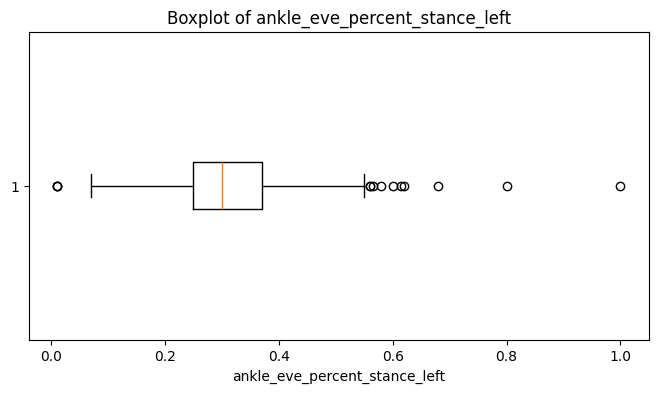

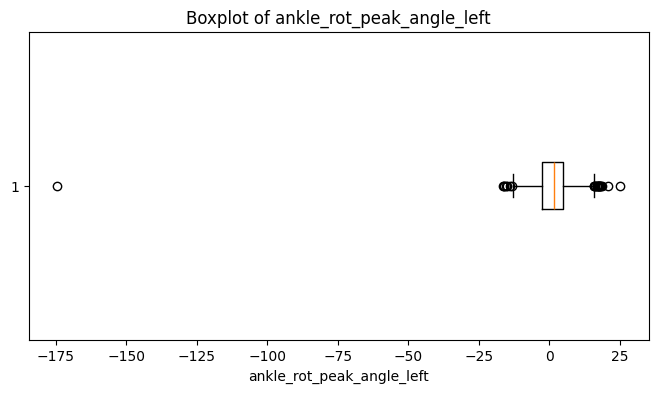

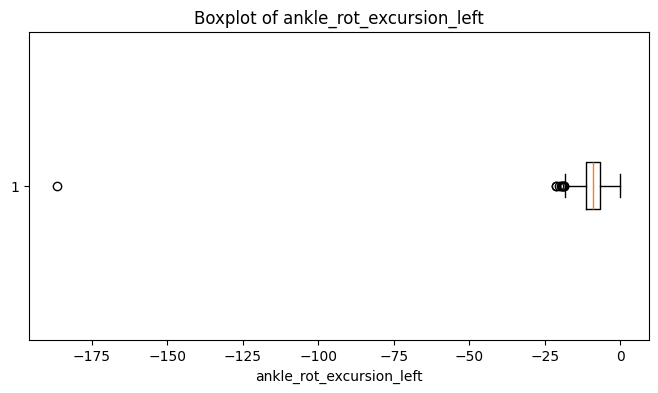

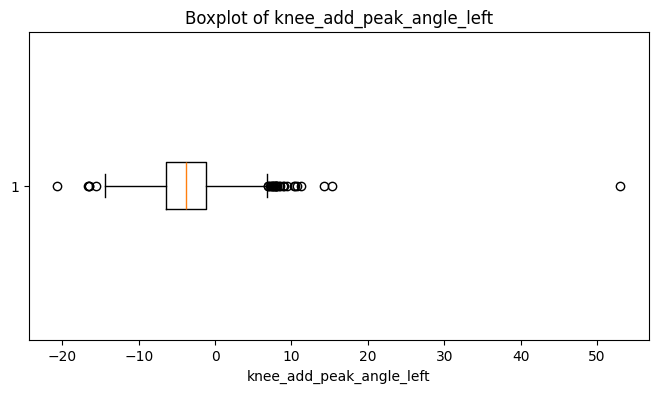

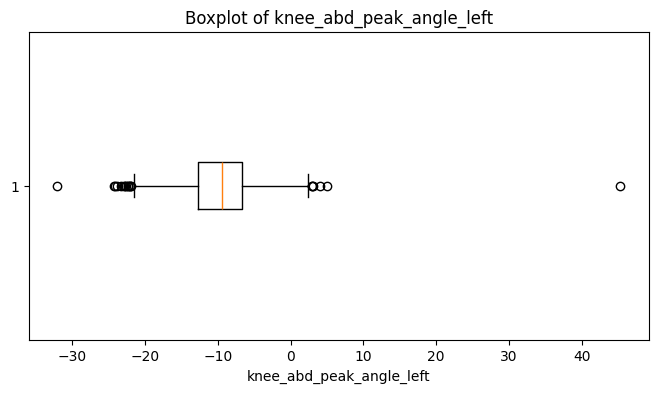

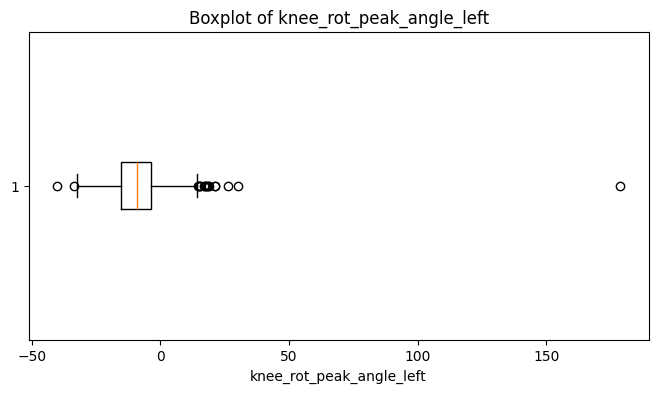

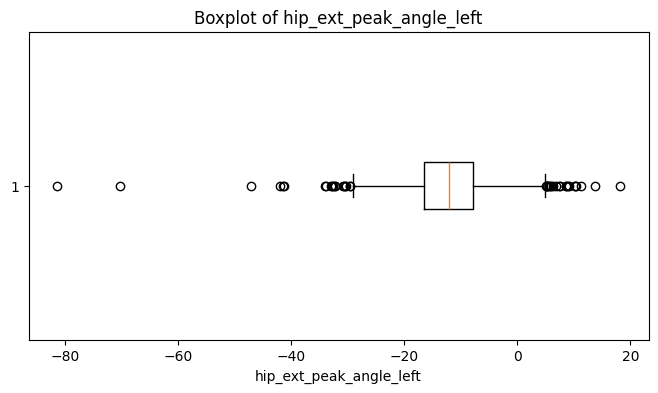

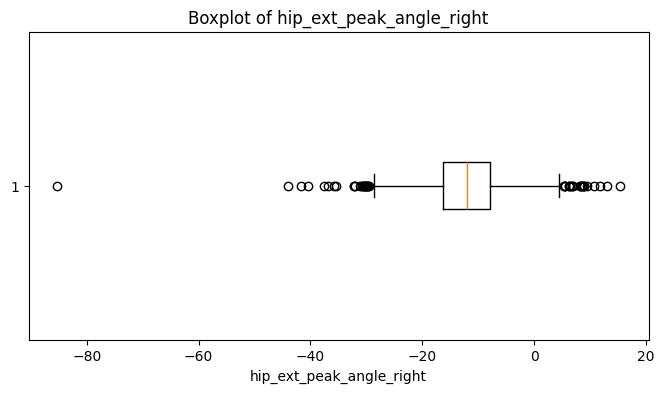

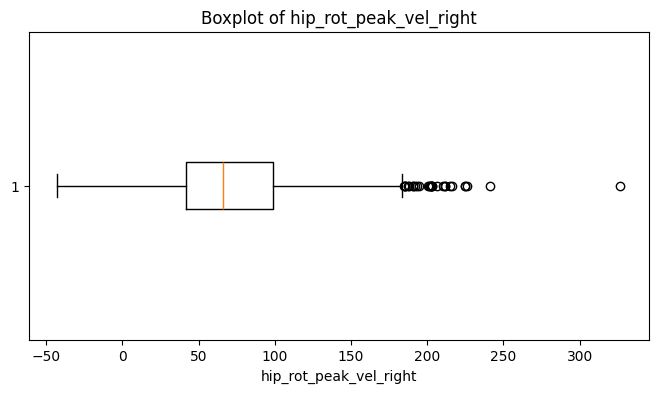

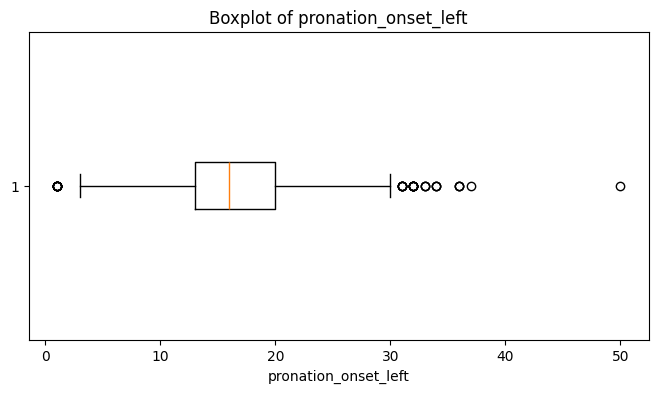

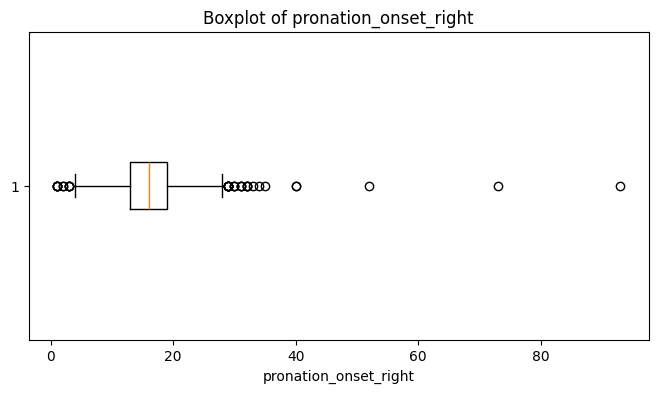

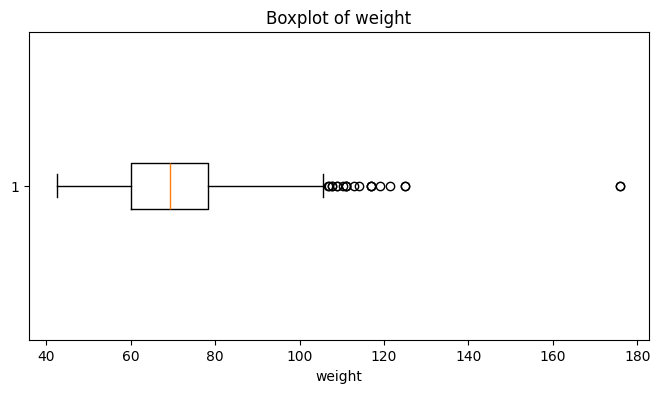

In [8]:
suspicuous_columns = [
    "ankle_eve_percent_stance_left",
    "ankle_rot_peak_angle_left",
    "ankle_rot_excursion_left",
    "knee_add_peak_angle_left",
    "knee_abd_peak_angle_left",
    "knee_rot_peak_angle_left",
    "hip_ext_peak_angle_left",
    "hip_ext_peak_angle_right",
    "hip_rot_peak_vel_right",
    "pronation_onset_left",
    "pronation_onset_right",
    "weight"
]

for col in suspicuous_columns:
    plot_boxplot(full_data_selected, col)


In [10]:
import numpy as np

outlier_ids = {}

for col in suspicuous_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = full_data_selected[col].quantile(0.25)
    Q3 = full_data_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier threshold
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Find outliers
    outliers = full_data_selected[(full_data_selected[col] < lower_bound) | (full_data_selected[col] > upper_bound)]
    if not outliers.empty:
        # Find the biggest outlier (farthest from the nearest bound)
        outlier_dists = np.maximum(
            np.abs(outliers[col] - lower_bound),
            np.abs(outliers[col] - upper_bound)
        )
        max_idx = outlier_dists.idxmax()
        outlier_id = outliers.loc[max_idx, "id"]
        outlier_ids[col] = outlier_id
    else:
        outlier_ids[col] = None

print("Biggest outlier IDs for each suspicious column:")
for col, oid in outlier_ids.items():
    print(f"{col}: {oid}")


Biggest outlier IDs for each suspicious column:
ankle_eve_percent_stance_left: 200369_20141016T184402
ankle_rot_peak_angle_left: 200378_20140911T155034
ankle_rot_excursion_left: 200378_20140911T155034
knee_add_peak_angle_left: 100540_20120621T151224
knee_abd_peak_angle_left: 100540_20120621T151224
knee_rot_peak_angle_left: 100540_20120621T151224
hip_ext_peak_angle_left: 100545_20120620T101120
hip_ext_peak_angle_right: 100545_20120620T101120
hip_rot_peak_vel_right: 101606_20150928T111707
pronation_onset_left: 101374_20150114T081238
pronation_onset_right: 100083_20110727T140025
weight: 101786_20160209T124451


In [11]:
import matplotlib
original_backend = matplotlib.get_backend()

In [24]:
%matplotlib qt5

marker_ts = loader.get_available_markers_timeseries("101786_20160209T124451")
visualize_marker_trajectories(marker_ts, playback_speed=0.5)

The player requires a interactive backend, please run the following command:
%matplotlib qt5


In [25]:
matplotlib.pyplot.switch_backend(original_backend)
plt.show()  # To purge the player frame

In [27]:
ids_to_drop =[
    "100540_20120621T151224",
    "200378_20140911T155034",
    "101606_20150928T111707",
    "101374_20150114T081238",
    "101786_20160209T124451",
]

In [30]:
filtered_data = full_data_selected[~full_data_selected.id.isin(ids_to_drop)]
display(filtered_data.head())
print(filtered_data.info(verbose=True))

,id,speed_output,hz,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,2.489233,200,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,2.722687,200,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,2.949904,200,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,2.688014,200,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,2.928598,200,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False


<class 'pandas.core.frame.DataFrame'>
Index: 1807 entries, 0 to 1811
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1807 non-null   object 
 1   speed_output                    1807 non-null   float64
 2   hz                              1807 non-null   int64  
 3   step_width_left                 1807 non-null   float64
 4   step_width_right                1807 non-null   float64
 5   stride_rate_left                1807 non-null   float64
 6   stride_rate_right               1807 non-null   float64
 7   stride_length_left              1807 non-null   float64
 8   stride_length_right             1807 non-null   float64
 9   swing_time_left                 1807 non-null   float64
 10  swing_time_right                1807 non-null   float64
 11  stance_time_left                1807 non-null   float64
 12  stance_time_right               1807 no

### Missing or invalid values:
Let's take a look at the missing or invalid values in the data.